In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError, pauli_error 
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter

In [3]:
ideal = Statevector([0.93386131+4.78877691e-15j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j,
             0.35763538+2.08311796e-15j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j,
             0.        +0.00000000e+00j, 0.        +0.00000000e+00j],
            dims=(2, 2, 2, 2))

# Circuit

In [5]:
theta = 0.73146

# Create custom gates
ry_sub = QuantumCircuit(1, name='RY_custom')
ry_sub.ry(theta, 0)
RY_custom = ry_sub.to_gate()

h_sub = QuantumCircuit(1, name='H_custom')
h_sub.h(0)
H_custom = h_sub.to_gate()

In [ ]:
def encoding_circ(qc: QuantumCircuit):
    for i in range(4):
        qc.ry(theta, i)
    qc.id(0)
    qc.append(H_custom, [3])
    qc.id(0)
    qc.cz(1, 2)
    qc.cz(1, 3)
    qc.cz(0, 1)
    qc.id(2)
    qc.append(H_custom, [3])
    for i in range(3):
        qc.h(i)
    qc.append(H_custom, [3])

In [11]:
circuit = QuantumCircuit(4, 3)
encoding_circ(circuit)

# Simulations

In [8]:
one_qubit_noise = []
for i in range(1, 7):
    one_qubit_noise.append(np.round((0.00002*i), 5)) # Quantinuum 1Q Gate 
    
meas_noise = []
for i in range(1, 7):
    meas_noise.append(np.round((0.0015*i), 4)) # Quantinuum SPAM 
    
two_qubit_noise = []
for i in range(1, 7):
    two_qubit_noise.append(np.round((0.0016*i), 4)) # Quantinuum 2Q Gate

In [9]:
print(one_qubit_noise)
print(two_qubit_noise)
print(meas_noise)

[np.float64(2e-05), np.float64(4e-05), np.float64(6e-05), np.float64(8e-05), np.float64(0.0001), np.float64(0.00012)]
[np.float64(0.0016), np.float64(0.0032), np.float64(0.0048), np.float64(0.0064), np.float64(0.008), np.float64(0.0096)]
[np.float64(0.0015), np.float64(0.003), np.float64(0.0045), np.float64(0.006), np.float64(0.0075), np.float64(0.009)]


In [10]:
depol_probs_idle = []
for i in range(1, 7):
    depol_probs_idle.append(np.round(1.896 * 10**(-2) * i, 5))
print(depol_probs_idle)

[np.float64(0.01896), np.float64(0.03792), np.float64(0.05688), np.float64(0.07584), np.float64(0.0948), np.float64(0.11376)]


In [24]:
fidelity_results = {}
sample_err_rate = []

for i in range(len(one_qubit_noise)):
    # New noise model for each depolarizing probability
    noise_model = NoiseModel()

    # Apply depolarizing error with probability p
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[i], 1), ['H_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(depol_probs_idle[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[i], 2), ['cz']) 

    # Keep readout error constant
    readout_err = ReadoutError([[1-meas_noise[i], meas_noise[i]],  # P(measured 0 | actual 0), P(1 | 0)
                            [meas_noise[i], 1-meas_noise[i]]]) # P(0 | 1), P(1 | 1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    # A copy of the circuit
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1, 2], [0, 1, 2]) 
    meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

    # Run simulation
    backend = AerSimulator(noise_model=noise_model)
    transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
    job = backend.run(transpiled, shots=1_000_000)
    result = job.result()
    
    # Extract final state and compute fidelity 
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    fidelity_results[i] = sumfid
    
    # Calculating error rate for uncertainty calculations
    sample_err_rate.append(1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )
    
infidelities = [1 - fidelity_results[p] for p in range(len(one_qubit_noise))]

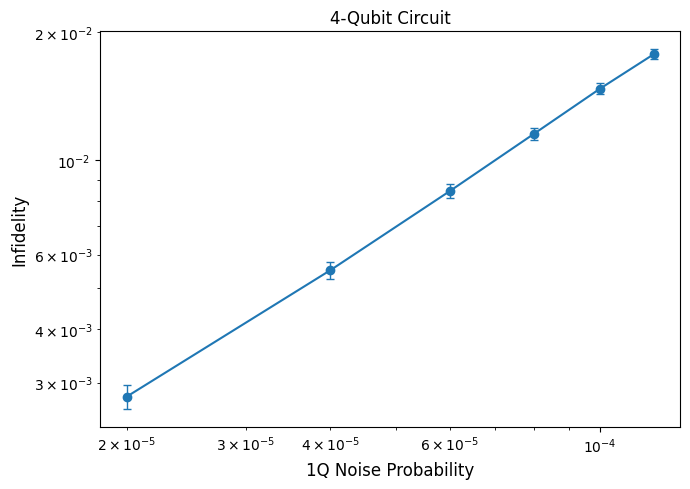

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    one_qubit_noise,
    infidelities,
    yerr=sample_err_rate,
    fmt='o-',
    capsize=3,
    elinewidth=1,
    markeredgewidth=1
)

ax.set_xlabel("1Q Noise Probability", fontsize=12)
ax.set_ylabel("Infidelity", fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
#ax.grid(True)
"""
# Turn off both major and minor tick formatters (default log labels)
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

# Set desired ticks and labels
ax.set_xticks(depol_probs_encoding)
ax.set_xticklabels([f"{x:.2e}" for x in depol_probs_encoding], fontsize=8, rotation=30)
"""
plt.title("4-Qubit Circuit")
plt.tight_layout()
plt.show()

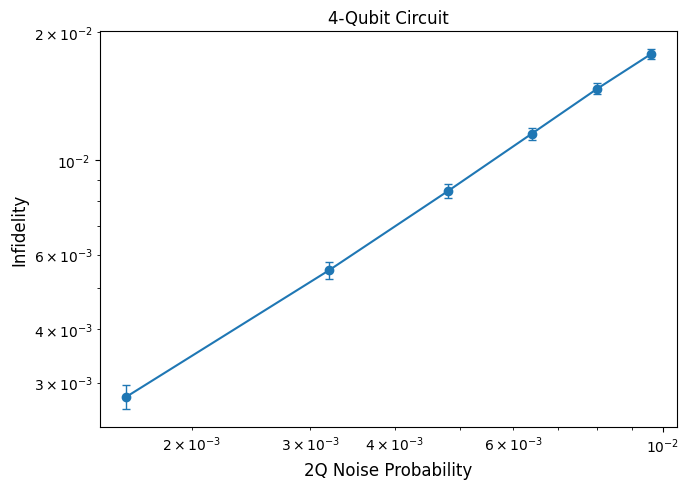

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    two_qubit_noise,
    infidelities,
    yerr=sample_err_rate,
    fmt='o-',
    capsize=3,
    elinewidth=1,
    markeredgewidth=1
)

ax.set_xlabel("2Q Noise Probability", fontsize=12)
ax.set_ylabel("Infidelity", fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
#ax.grid(True)
"""
# Turn off both major and minor tick formatters (default log labels)
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

# Set desired ticks and labels
ax.set_xticks(depol_probs_encoding)
ax.set_xticklabels([f"{x:.2e}" for x in depol_probs_encoding], fontsize=8, rotation=30)
"""
plt.title("4-Qubit Circuit")
plt.tight_layout()
plt.show()

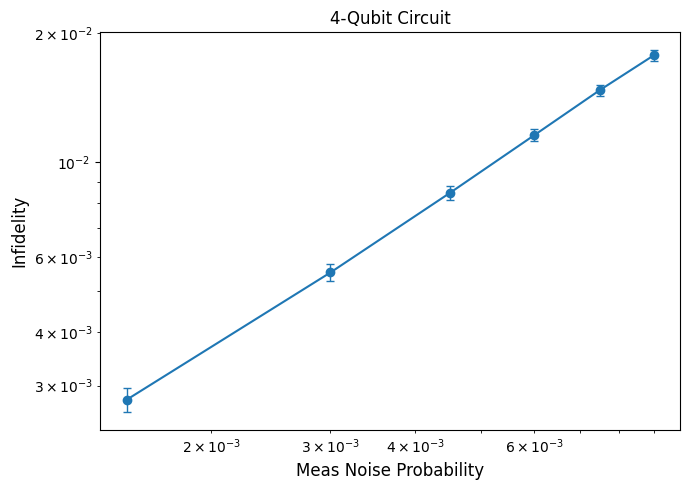

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    meas_noise,
    infidelities,
    yerr=sample_err_rate,
    fmt='o-',
    capsize=3,
    elinewidth=1,
    markeredgewidth=1
)

ax.set_xlabel("Meas Noise Probability", fontsize=12)
ax.set_ylabel("Infidelity", fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
#ax.grid(True)
"""
# Turn off both major and minor tick formatters (default log labels)
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

# Set desired ticks and labels
ax.set_xticks(depol_probs_encoding)
ax.set_xticklabels([f"{x:.2e}" for x in depol_probs_encoding], fontsize=8, rotation=30)
"""
plt.title("4-Qubit Circuit")
plt.tight_layout()
plt.show()

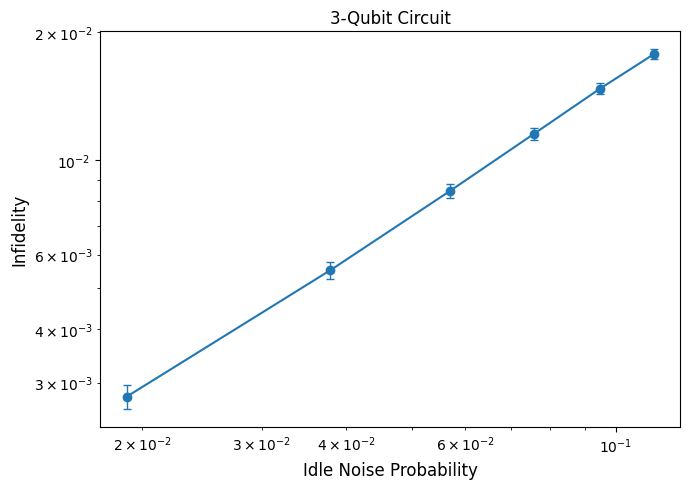

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    depol_probs_idle,
    infidelities,
    yerr=sample_err_rate,
    fmt='o-',
    capsize=3,
    elinewidth=1,
    markeredgewidth=1
)

ax.set_xlabel("Idle Noise Probability", fontsize=12)
ax.set_ylabel("Infidelity", fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
#ax.grid(True)
"""
# Turn off both major and minor tick formatters (default log labels)
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

# Set desired ticks and labels
ax.set_xticks(depol_probs_encoding)
ax.set_xticklabels([f"{x:.2e}" for x in depol_probs_encoding], fontsize=8, rotation=30)
"""
plt.title("3-Qubit Circuit")
plt.tight_layout()
plt.show()

In [35]:
input_state = QuantumCircuit(2, 1)
input_state.ry(theta, 0)

ideal_input = QuantumCircuit(2)
ideal_input.append(RY_custom, [0])
ideal_input = Statevector(ideal_input)

In [36]:
input_fidelity_results = {}
input_sample_err_rate = []

for i in range(len(one_qubit_noise)):
    # New noise model for each depolarizing probability
    nm = NoiseModel()

    # Apply depolarizing error with probability p
    nm.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[i], 1), ['ry'])
    
    # A copy of the circuit
    input_copy = input_state.copy()
    input_copy.measure([1], [0]) 
    input_copy.save_statevector(label='state_post', pershot=True, conditional=True)

    # Run simulation
    backend = AerSimulator(noise_model=nm)
    transpiled = transpile(input_copy, backend, optimization_level=0)
    job = backend.run(transpiled, shots=5_000_000)
    result = job.result()
    
    # Extract final state and compute fidelity 
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal_input)
    sumfid /= num_meas
    
    input_fidelity_results[i] = sumfid
    
    # Calculating error rate for uncertainty calculations
    input_sample_err_rate.append(1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )

input_infidelities = [1 - input_fidelity_results[p] for p in range(len(one_qubit_noise))]

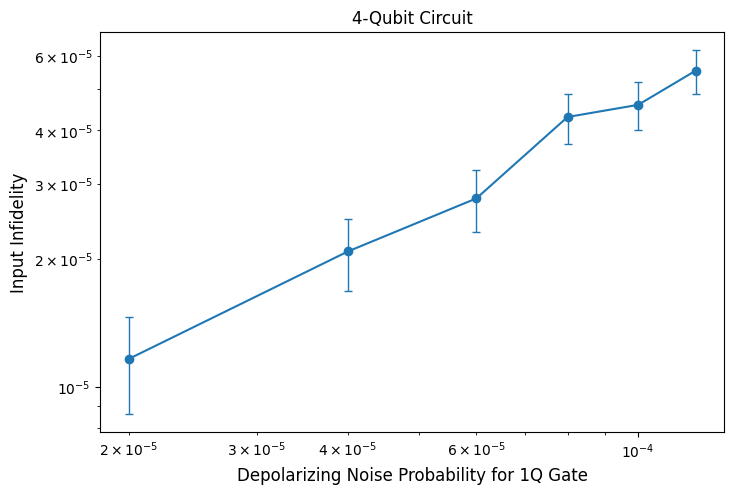

In [37]:
plt.figure(figsize=(7, 5))
plt.errorbar(
    one_qubit_noise,
    input_infidelities,
    yerr=input_sample_err_rate,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.title("4-Qubit Circuit")
plt.xlabel("Depolarizing Noise Probability for 1Q Gate", fontsize=12)
plt.ylabel("Input Infidelity", fontsize=12)
#plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

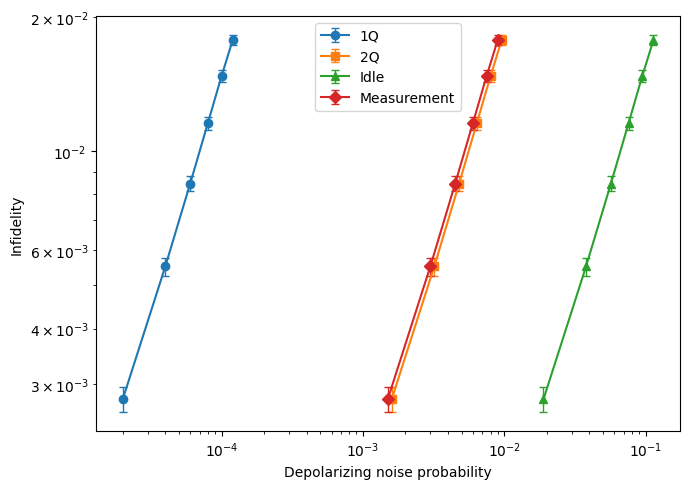

In [38]:
series = {
    "1Q": np.array(one_qubit_noise),
    "2Q": np.array(two_qubit_noise),
    "Idle": np.array(depol_probs_idle),
    "Measurement": np.array(meas_noise)
}

markers = ['o', 's', '^', 'D']  # just to differentiate curves
plt.figure(figsize=(7,5))

for (label, x_vals), m in zip(series.items(), markers):
    plt.errorbar(
        x_vals,
        infidelities,
        yerr=sample_err_rate,
        fmt=f'{m}-',
        capsize=3,
        elinewidth=1,
        label=label
    )

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Depolarizing noise probability')
plt.ylabel('Infidelity')
#plt.grid(True, which='both', linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

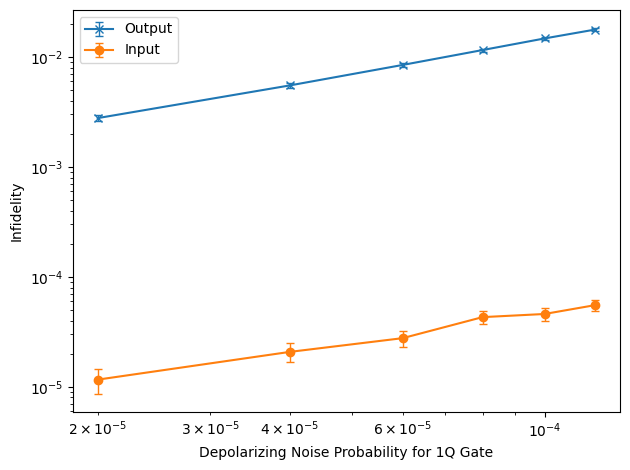

In [39]:
plt.errorbar(
    one_qubit_noise,
    infidelities,
    yerr=sample_err_rate,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output'
)
plt.errorbar(
    one_qubit_noise,
    input_infidelities,
    yerr=input_sample_err_rate,
    fmt=f'o-',
    capsize=3,
    elinewidth=1,
    label='Input'
)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Depolarizing Noise Probability for 1Q Gate')
plt.ylabel('Infidelity')
#plt.grid(True, which='both', linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
print(infidelities)
print(sample_err_rate)
print(input_infidelities)
print(input_sample_err_rate)

[0.0027788735102936, 0.00551535187173513, 0.00846027178662101, 0.011556423927027049, 0.014734060708511465, 0.01774945310867826]
[np.float64(0.0001804185180584411), np.float64(0.0002574282262600342), np.float64(0.0003224791273842764), np.float64(0.00038112456805192325), np.float64(0.0004357947448592744), np.float64(0.0004832345879524819)]
[1.1618433938709316e-05, 2.0796900495279047e-05, 2.7704567712172334e-05, 4.30277324527939e-05, 4.5953833608503025e-05, 5.5326101155772633e-05]
[np.float64(2.987736844135283e-06), np.float64(3.997291868456359e-06), np.float64(4.613608538435297e-06), np.float64(5.749577805493501e-06), np.float64(5.941853829792449e-06), np.float64(6.5196470939610045e-06)]
